# LastFM Dataset — Release Year Analysis

Investigates **when** the songs in our LastFM collection were originally released.

**Pipeline:**
1. Collect all song IDs from `dataset/lastfm/` (folder names)
2. Look up each ID in the metadata JSON at `/mnt/Aimir_HD/lastfm/metadata/`
3. Query **MusicBrainz** (free, no API key required) using `artist + title` to retrieve the earliest known release year
4. Cache results to disk so the notebook can be resumed without re-querying
5. Plot and summarise the year distribution


In [1]:
import os, json, time, re, pickle
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import musicbrainzngs as mb

# ── Paths ──────────────────────────────────────────────────────────────────
DATASET_DIR  = Path("/workspace/dataset/lastfm")
METADATA_DIR = Path("/mnt/Aimir_HD/lastfm/metadata")
CACHE_FILE   = Path("/workspace/src/lastfm_year_cache.pkl")    # persists across runs

# ── MusicBrainz client setup ────────────────────────────────────────────────
mb.set_useragent("AimirYearAnalysis", "0.1", "research@example.com")
mb.set_rate_limit(limit_or_interval=1.0)   # 1 request/s — MB asks for ≤ 1 r/s

print("Paths set up.")
print(f"  Dataset IDs  : {DATASET_DIR}")
print(f"  Metadata JSONs: {METADATA_DIR}")
print(f"  Cache file   : {CACHE_FILE}")


Paths set up.
  Dataset IDs  : /workspace/dataset/lastfm
  Metadata JSONs: /mnt/Aimir_HD/lastfm/metadata
  Cache file   : /workspace/src/lastfm_year_cache.pkl


In [2]:
# ── 1. Collect all IDs present in the dataset ──────────────────────────────
dataset_ids = sorted([
    d.name for d in DATASET_DIR.iterdir()
    if d.is_dir() and not d.name.startswith(".")
])

print(f"Total song IDs in dataset/lastfm : {len(dataset_ids)}")
print("First 5:", dataset_ids[:5])


Total song IDs in dataset/lastfm : 19913
First 5: ['00076eee1c1ddf7a880fb205b564bf8e', '000a0c8a581b5fb4ba3c2c894640a043', '000a6052f62d5a43d698cf5b0669bf10', '000cba815954f6de5a9fb500e19865d1', '0010f9e0cc7212830e8abb16e69f419e']


In [10]:
# ── 2. Load metadata (artist + title) for each dataset ID ──────────────────
# Some IDs may not have a corresponding metadata file — we track those separately.

records = []          # list of dicts: {id, artist, title}
missing_meta = []     # IDs with no metadata JSON on disk

for song_id in dataset_ids:
    meta_path = METADATA_DIR / f"{song_id}.json"
    if meta_path.exists():
        with open(meta_path) as f:
            m = json.load(f)
        records.append({
            "id":     song_id,
            "artist": m.get("artist", ""),
            "title":  m.get("name", ""),
        })
    else:
        missing_meta.append(song_id)

df_meta = pd.DataFrame(records)
print(f"Metadata loaded   : {len(df_meta)}")
print(f"Missing metadata  : {len(missing_meta)}")
df_meta.head()


Metadata loaded   : 19913
Missing metadata  : 0


,id,artist,title
0,00076eee1c1ddf7a880fb205b564bf8e,Twin Shadow,Slow
1,000a0c8a581b5fb4ba3c2c894640a043,Femi Kuti,Truth Don Die
2,000a6052f62d5a43d698cf5b0669bf10,Hootie & The Blowfish,Only Wanna Be With You
3,000cba815954f6de5a9fb500e19865d1,Ayreon,Farside of the World
4,0010f9e0cc7212830e8abb16e69f419e,Mayhem,Buried By Time and Dust


In [11]:
# ── 3. MusicBrainz year look-up with disk cache ─────────────────────────────
# The cache stores  {id -> year_or_None}  so interrupted runs resume cleanly.
# MusicBrainz rate-limit: ≤ 1 request/second without a registered key.
# Full 19 k songs ≈ 5–6 hours; re-running just fills in what's missing.

def extract_year(release):
    """Pull the earliest 4-digit year out of a release dict."""
    for field in ("date", "first-release-date"):
        val = release.get(field, "")
        m = re.match(r"(\d{4})", str(val))
        if m:
            return int(m.group(1))
    return None

def lookup_year_mb(artist: str, title: str) -> int | None:
    """Search MusicBrainz for a recording and return its earliest release year."""
    try:
        result = mb.search_recordings(
            query=f'recording:"{title}" AND artist:"{artist}"',
            limit=5
        )
        years = []
        for rec in result.get("recording-list", []):
            for rel in rec.get("release-list", []):
                y = extract_year(rel)
                if y and 1900 <= y <= 2030:
                    years.append(y)
        return min(years) if years else None
    except Exception:
        return None

# ── Load cache ────────────────────────────────────────────────────────────
year_cache: dict[str, int | None] = {}
if CACHE_FILE.exists():
    with open(CACHE_FILE, "rb") as f:
        year_cache = pickle.load(f)
    print(f"Cache loaded: {len(year_cache)} entries already resolved")
else:
    print("No cache found — starting fresh")

# ── Query only what is missing ────────────────────────────────────────────
to_query = df_meta[~df_meta["id"].isin(year_cache)].copy()
print(f"Remaining to query: {len(to_query)} / {len(df_meta)}")


Cache loaded: 500 entries already resolved
Remaining to query: 19413 / 19913


In [5]:
# ── 4. Run queries — safe to interrupt and re-run ────────────────────────────
# Set MAX_QUERIES to a smaller number (e.g. 200) for a quick preview,
# or to len(to_query) to resolve everything.

MAX_QUERIES = 500   # ← change to len(to_query) for the full dataset

rows = to_query.head(MAX_QUERIES).itertuples(index=False)
save_every = 100    # checkpoint the cache every N queries

for i, row in enumerate(rows, 1):
    year = lookup_year_mb(row.artist, row.title)
    year_cache[row.id] = year

    if i % save_every == 0:
        with open(CACHE_FILE, "wb") as f:
            pickle.dump(year_cache, f)
        resolved = sum(1 for v in year_cache.values() if v is not None)
        print(f"  {i:>5} queried | {resolved} resolved so far (checkpoint saved)")

# Final save
with open(CACHE_FILE, "wb") as f:
    pickle.dump(year_cache, f)

resolved = sum(1 for v in year_cache.values() if v is not None)
print(f"\nDone. {len(year_cache)} queried in total, {resolved} with a year.")


    100 queried | 98 resolved so far (checkpoint saved)
    200 queried | 194 resolved so far (checkpoint saved)
    300 queried | 288 resolved so far (checkpoint saved)
    400 queried | 385 resolved so far (checkpoint saved)
    500 queried | 482 resolved so far (checkpoint saved)

Done. 500 queried in total, 482 with a year.


In [12]:
# ── 5. Build the analysis dataframe from cached results ──────────────────────
df_meta["year"] = df_meta["id"].map(year_cache)

n_total    = len(df_meta)
n_resolved = df_meta["year"].notna().sum()
n_missing  = df_meta["year"].isna().sum()

print(f"Songs in dataset    : {n_total}")
print(f"Year resolved       : {n_resolved}  ({100*n_resolved/n_total:.1f}%)")
print(f"Year still unknown  : {n_missing}   ({100*n_missing/n_total:.1f}%)")
print()

df_years = df_meta[df_meta["year"].notna()].copy()
df_years["year"] = df_years["year"].astype(int)

print("Year distribution summary:")
print(df_years["year"].describe(percentiles=[.1, .25, .5, .75, .9]).to_string())


Songs in dataset    : 19913
Year resolved       : 482  (2.4%)
Year still unknown  : 19431   (97.6%)

Year distribution summary:
count     482.000000
mean     2002.039419
std         9.648527
min      1956.000000
10%      1990.100000
25%      1997.000000
50%      2004.000000
75%      2008.000000
90%      2012.000000
max      2020.000000


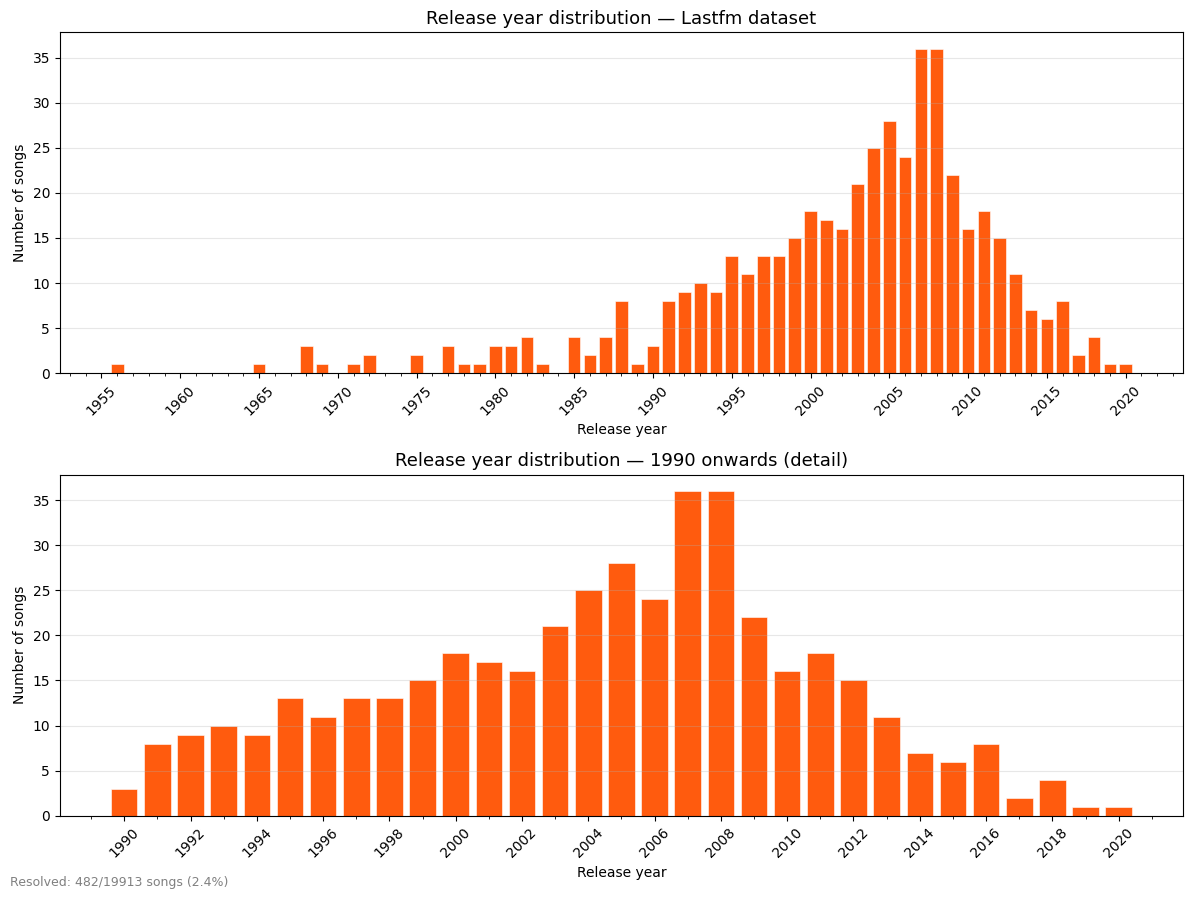

Figure saved to Figures/lastfm_year_distribution.png


In [14]:
# ── 6. Plot — histogram of release years ──────────────────────────────────────
year_counts = df_years["year"].value_counts().sort_index()
year_counts = year_counts[(year_counts.index >= 1950) & (year_counts.index <= 2025)]

fig, axes = plt.subplots(2, 1, figsize=(12, 9))

# --- Panel A: full range histogram ---
ax = axes[0]
ax.bar(year_counts.index, year_counts.values, width=0.8, color="#FF5B0E", edgecolor="white", linewidth=0.4)
ax.set_title("Release year distribution — Lastfm dataset", fontsize=13)
ax.set_xlabel("Release year")
ax.set_ylabel("Number of songs")
ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
ax.xaxis.set_minor_locator(mticker.MultipleLocator(1))
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.3)

# --- Panel B: zoomed to 1990–2024 (where most songs likely cluster) ---
ax2 = axes[1]
y_zoom = year_counts[(year_counts.index >= 1990)]
ax2.bar(y_zoom.index, y_zoom.values, width=0.8, color="#FF5B0E", edgecolor="white", linewidth=0.4)
ax2.set_title("Release year distribution — 1990 onwards (detail)", fontsize=13)
ax2.set_xlabel("Release year")
ax2.set_ylabel("Number of songs")
ax2.xaxis.set_major_locator(mticker.MultipleLocator(2))
ax2.xaxis.set_minor_locator(mticker.MultipleLocator(1))
ax2.tick_params(axis="x", rotation=45)
ax2.grid(axis="y", alpha=0.3)

# Annotate coverage
fig.text(0.01, 0.01,
         f"Resolved: {n_resolved}/{n_total} songs ({100*n_resolved/n_total:.1f}%)",
         fontsize=9, color="grey")

plt.tight_layout()
plt.savefig("/workspace/src/../Figures/lastfm_year_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to Figures/lastfm_year_distribution.png")


In [8]:
# ── 7. Decade breakdown table ─────────────────────────────────────────────────
df_years["decade"] = (df_years["year"] // 10 * 10).astype(str) + "s"
decade_table = (
    df_years.groupby("decade")
    .size()
    .reset_index(name="count")
    .assign(pct=lambda x: (x["count"] / x["count"].sum() * 100).round(1))
    .sort_values("decade")
)
print("Songs by decade:\n")
print(decade_table.to_string(index=False))


Songs by decade:

decade  count  pct
 1950s      1  0.2
 1960s      5  1.0
 1970s     10  2.1
 1980s     30  6.2
 1990s    104 21.6
 2000s    243 50.4
 2010s     88 18.3
 2020s      1  0.2


In [9]:
# ── 8. Export to CSV ──────────────────────────────────────────────────────────
out_csv = Path("/workspace/src/lastfm_years.csv")
df_meta[["id", "artist", "title", "year"]].to_csv(out_csv, index=False)
print(f"Saved: {out_csv}  ({len(df_meta)} rows)")
df_meta[["id", "artist", "title", "year"]].head(10)


Saved: /workspace/src/lastfm_years.csv  (19913 rows)


,id,artist,title,year
0,00076eee1c1ddf7a880fb205b564bf8e,Twin Shadow,Slow,2010.0
1,000a0c8a581b5fb4ba3c2c894640a043,Femi Kuti,Truth Don Die,1998.0
2,000a6052f62d5a43d698cf5b0669bf10,Hootie & The Blowfish,Only Wanna Be With You,1996.0
3,000cba815954f6de5a9fb500e19865d1,Ayreon,Farside of the World,1996.0
4,0010f9e0cc7212830e8abb16e69f419e,Mayhem,Buried By Time and Dust,1993.0
5,00123a6ae5c024de75d925a9f617497b,Dirty Projectors,Keep Your Name,2016.0
6,00133364fb6142e749a841028f35c672,Panda Bear,Alsatian Darn,2010.0
7,001387b0dbca7f3917446be53e561a65,Kollektiv Turmstrasse,Schwindelig,2010.0
8,00147d269b8087f4110867324e54f37f,Epica,La'petach Chatat Rovetz (The Final Embrace),NaN
9,00184816d14aa2aa2c22b5d31c2579ac,Songs: Ohia,Lightning Risked It All,2000.0
